In [50]:
import sys
import os
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..')))

from utilities.log_processor import LogProcessor

In [3]:
processor = LogProcessor('../../logs/nothing_bot@07_04_2025_1300.log')
processor.read_log()

In [4]:
import pandas as pd

price_data = pd.concat([pd.read_csv('../../round_data/prices_round_1_day_-2.csv',delimiter=';'), pd.read_csv('../../round_data/prices_round_1_day_-1.csv',delimiter=';'), pd.read_csv('../../round_data/prices_round_1_day_0.csv',delimiter=';'), processor.activities_log],axis=0)
price_data = price_data.reset_index(drop=True)

day_2 = pd.read_csv("../../round_data/trades_round_1_day_-2.csv",delimiter=';')
day_1 = pd.read_csv("../../round_data/trades_round_1_day_-1.csv",delimiter=';')
day_1['timestamp'] = day_1['timestamp'] + 1e6
day_0 = pd.read_csv("../../round_data/trades_round_1_day_0.csv",delimiter=';')
day_0['timestamp'] = day_0['timestamp'] + 1e6*2
processor.trade_history['timestamp'] = processor.trade_history['timestamp'] + 1e6*3
trade_history_data = pd.concat([day_2,day_1,day_0,processor.trade_history], axis=0)
trade_history_data = trade_history_data.reset_index(drop=True)

In [5]:
price_data['timestamp'] = price_data['timestamp'] + (price_data['day']+2)*1e6


In [6]:
# price_data.to_csv('../../round_data/price_data.csv', sep=';', index=False)
# trade_history_data.to_csv('../../round_data/trade_history.csv')

In [7]:
# import json
# json_trades = []
# for i, row in trade_history_data.iterrows():
#     json_trades.append({
#         "timestamp": row['timestamp'],
#         "buyer": "",
#         "seller": "",
#         "symbol": row['symbol'],
#         "currency": row['currency'],
#         "price": row['price'],
#         "quantity": row['quantity']
#     })
# with open("file.txt", "w") as f:
#     f.write("Trade History:\n")
#     json.dump(json_trades, f, indent=2)

In [8]:
kelp_data = price_data[price_data['product'] == "KELP"]
resin_data = price_data[price_data['product'] == "RAINFOREST_RESIN"]
squid_data = price_data[price_data['product'] == "SQUID_INK"]

kelp_trades = trade_history_data[trade_history_data['symbol'] == "KELP"]
resin_trades = trade_history_data[trade_history_data['symbol'] == "RAINFOREST_RESIN"]
squid_trades = trade_history_data[trade_history_data['symbol'] == "SQUID_INK"]

# Distribution of traded prices

<BarContainer object of 7 artists>

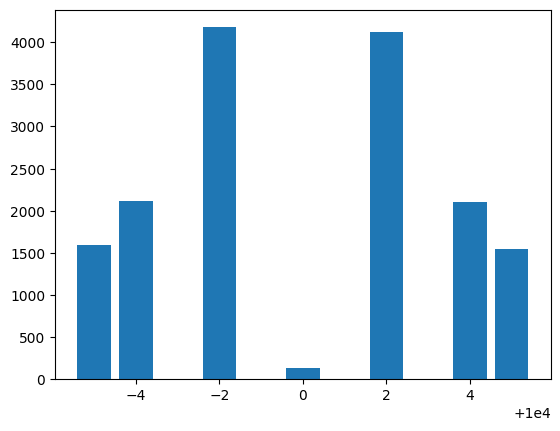

In [9]:
prices = resin_trades.price
prices = list(prices.unique())
quantities = [resin_trades[resin_trades.price==price]['quantity'].sum() for price in prices]
dictionary = {p:q for p,q in zip(prices,quantities)}
plt.bar(prices,quantities)
# dictionary

<BarContainer object of 47 artists>

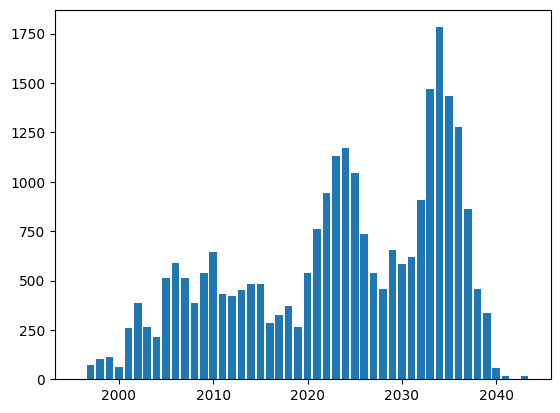

In [10]:
prices = kelp_trades.price
prices = list(prices.unique())
quantities = [kelp_trades[kelp_trades.price==price]['quantity'].sum() for price in prices]
dictionary = {p:q for p,q in zip(prices,quantities)}
plt.bar(prices,quantities)
# dictionary

<BarContainer object of 377 artists>

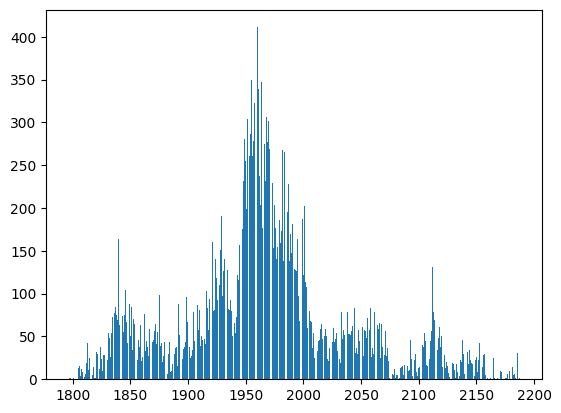

In [11]:
prices = squid_trades.price
prices = list(prices.unique())
quantities = [squid_trades[squid_trades.price==price]['quantity'].sum() for price in prices]
dictionary = {p:q for p,q in zip(prices,quantities)}
plt.bar(prices,quantities)

# Plots of bid ask mid

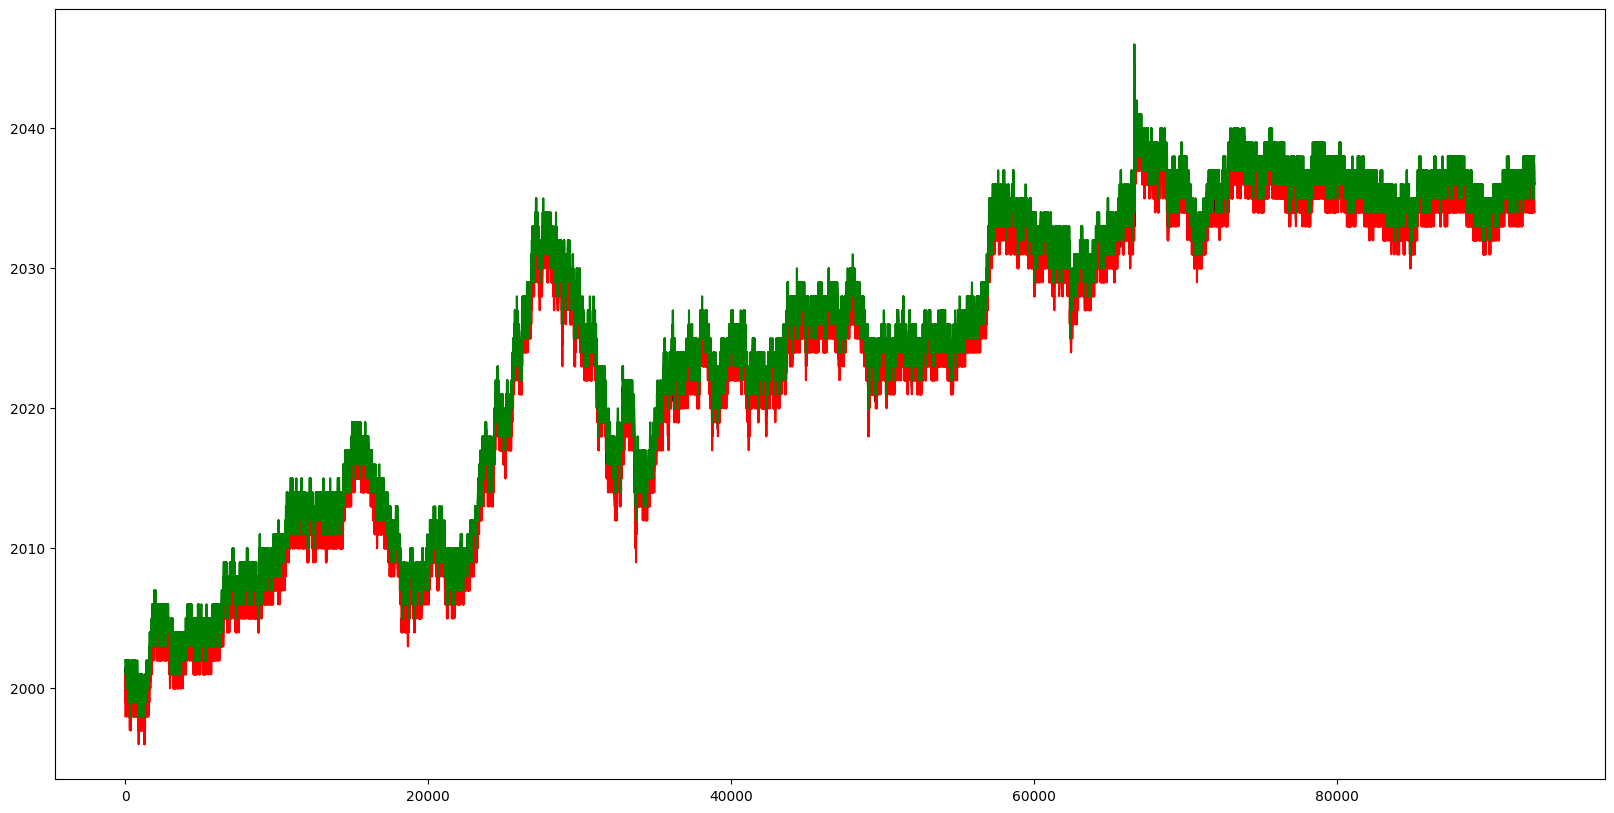

In [12]:
bid = kelp_data.bid_price_1
ask = kelp_data.ask_price_1
mid = kelp_data.mid_price
fig, ax = plt.subplots(figsize = (20,10))
ax.plot(mid, color='k')
ax.plot(bid, color='red')
ax.plot(ask, color='green')

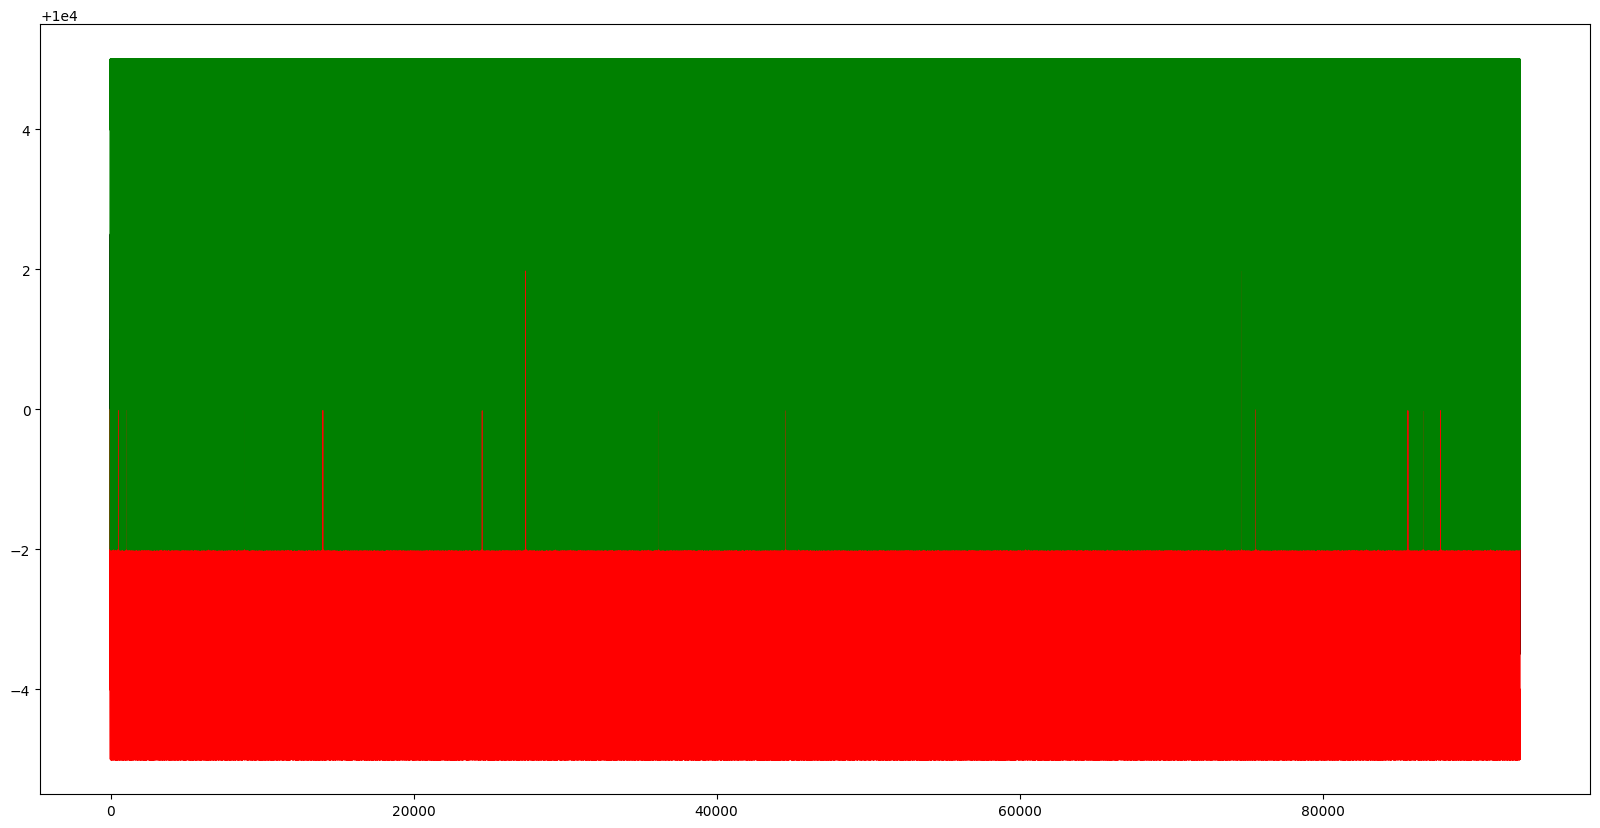

In [13]:
bid = resin_data.bid_price_1
ask = resin_data.ask_price_1
mid = resin_data.mid_price
fig, ax = plt.subplots(figsize = (20,10))
ax.plot(mid, color='k')
ax.plot(bid, color='red')
ax.plot(ask, color='green')

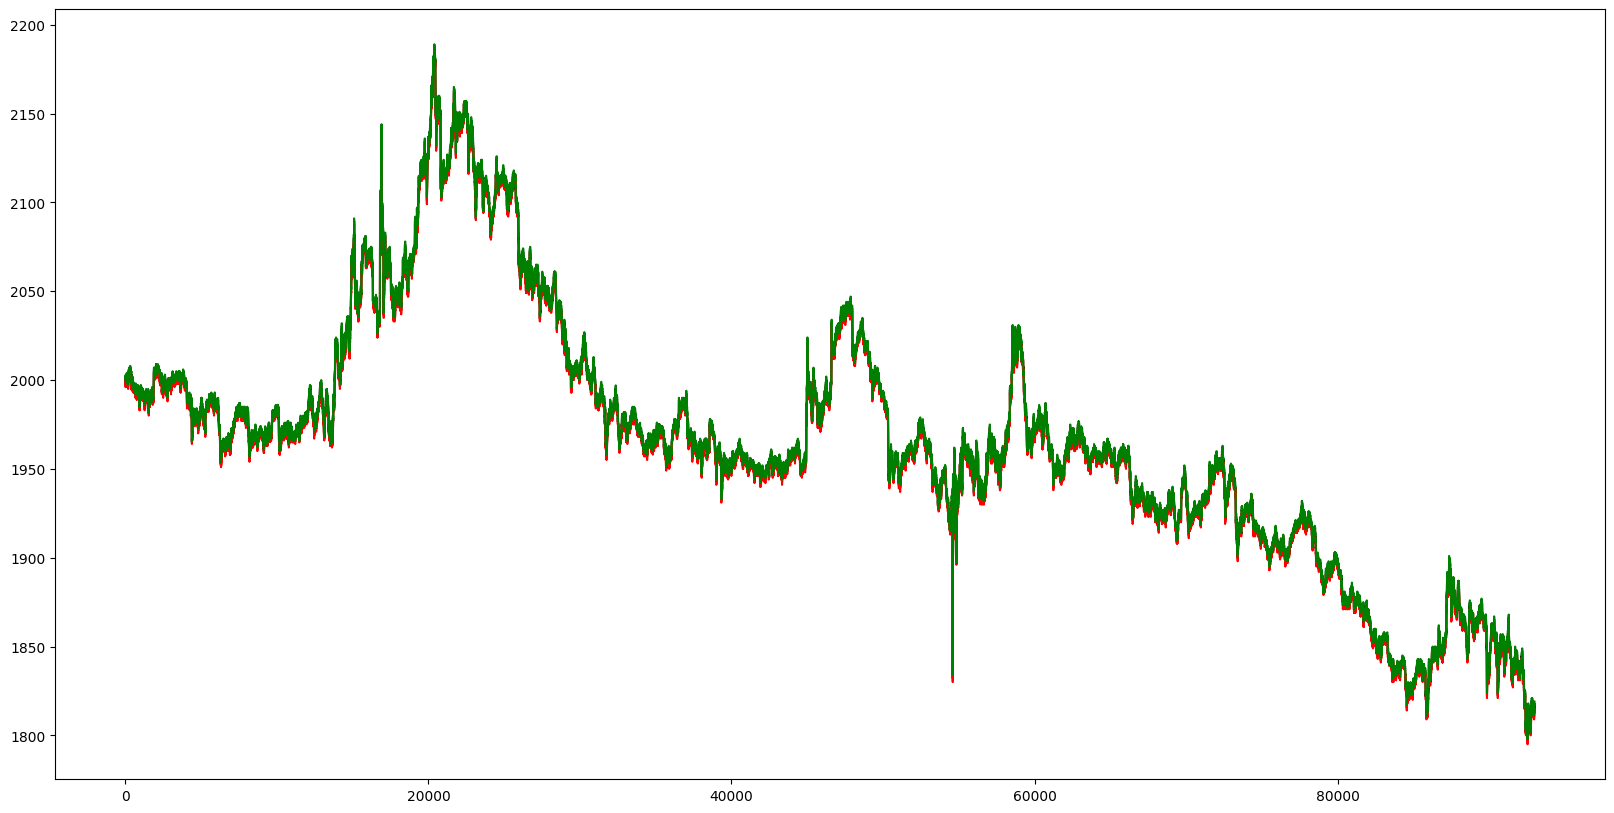

In [14]:
bid = squid_data.bid_price_1
ask = squid_data.ask_price_1
mid = squid_data.mid_price
fig, ax = plt.subplots(figsize = (20,10))
ax.plot(mid, color='k')
ax.plot(bid, color='red')
ax.plot(ask, color='green')

# Distribution of order book volumes

<BarContainer object of 26 artists>

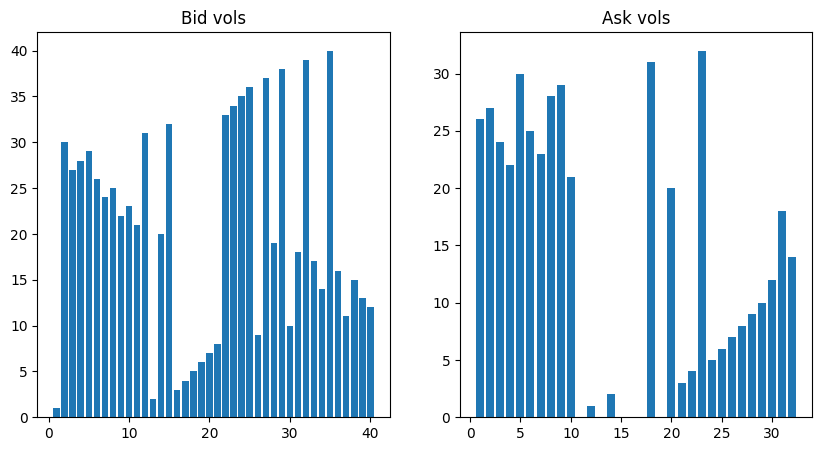

In [32]:
fig,ax = plt.subplots(ncols=2,figsize=(10,5))

bid_vols = kelp_data[['bid_volume_1','bid_volume_2','bid_volume_3']].values.flatten()
bid_vols = bid_vols[~np.isnan(bid_vols)]
ax[0].bar(np.unique(bid_vols),pd.Series(bid_vols).value_counts().to_dict())
ax[0].set_title('Bid vols')

ask_vols = kelp_data[['ask_volume_1','ask_volume_2','ask_volume_3']].values.flatten()
ask_vols = ask_vols[~np.isnan(ask_vols)]
ax[1].set_title('Ask vols')
ax[1].bar(np.unique(ask_vols),pd.Series(ask_vols).value_counts().to_dict())

<BarContainer object of 26 artists>

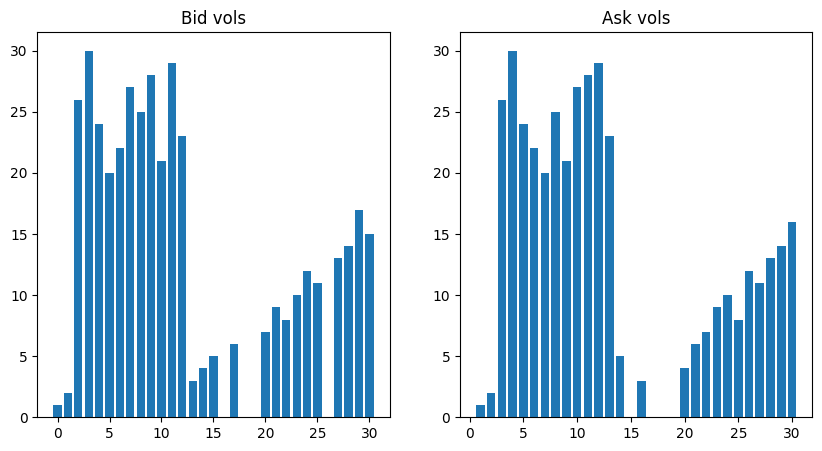

In [33]:
fig,ax = plt.subplots(ncols=2,figsize=(10,5))

bid_vols = resin_data[['bid_volume_1','bid_volume_2','bid_volume_3']].values.flatten()
bid_vols = bid_vols[~np.isnan(bid_vols)]
ax[0].bar(np.unique(bid_vols),pd.Series(bid_vols).value_counts().to_dict())
ax[0].set_title('Bid vols')

ask_vols = resin_data[['ask_volume_1','ask_volume_2','ask_volume_3']].values.flatten()
ask_vols = ask_vols[~np.isnan(ask_vols)]
ax[1].set_title('Ask vols')
ax[1].bar(np.unique(ask_vols),pd.Series(ask_vols).value_counts().to_dict())

<BarContainer object of 26 artists>

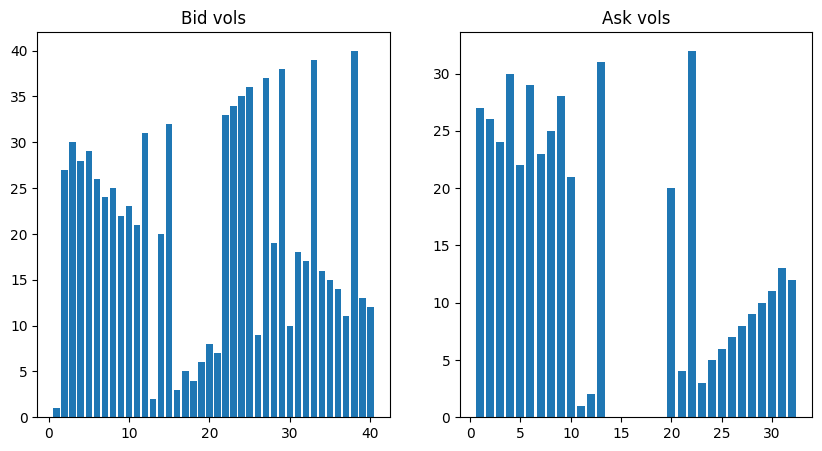

In [34]:
fig,ax = plt.subplots(ncols=2,figsize=(10,5))

bid_vols = squid_data[['bid_volume_1','bid_volume_2','bid_volume_3']].values.flatten()
bid_vols = bid_vols[~np.isnan(bid_vols)]
ax[0].bar(np.unique(bid_vols),pd.Series(bid_vols).value_counts().to_dict())
ax[0].set_title('Bid vols')

ask_vols = squid_data[['ask_volume_1','ask_volume_2','ask_volume_3']].values.flatten()
ask_vols = ask_vols[~np.isnan(ask_vols)]
ax[1].set_title('Ask vols')
ax[1].bar(np.unique(ask_vols),pd.Series(ask_vols).value_counts().to_dict())

# Mean Reversion in Squid Ink

Regressions

C:\Users\Conrad\AppData\Local\Temp\ipykernel_5492\455887943.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  squid_data['mid_price_diff'] = changes
C:\Users\Conrad\AppData\Local\Temp\ipykernel_5492\455887943.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  squid_data['total_bid_vol'] = total_volume
C:\Users\Conrad\AppData\Local\Temp\ipykernel_5492\455887943.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

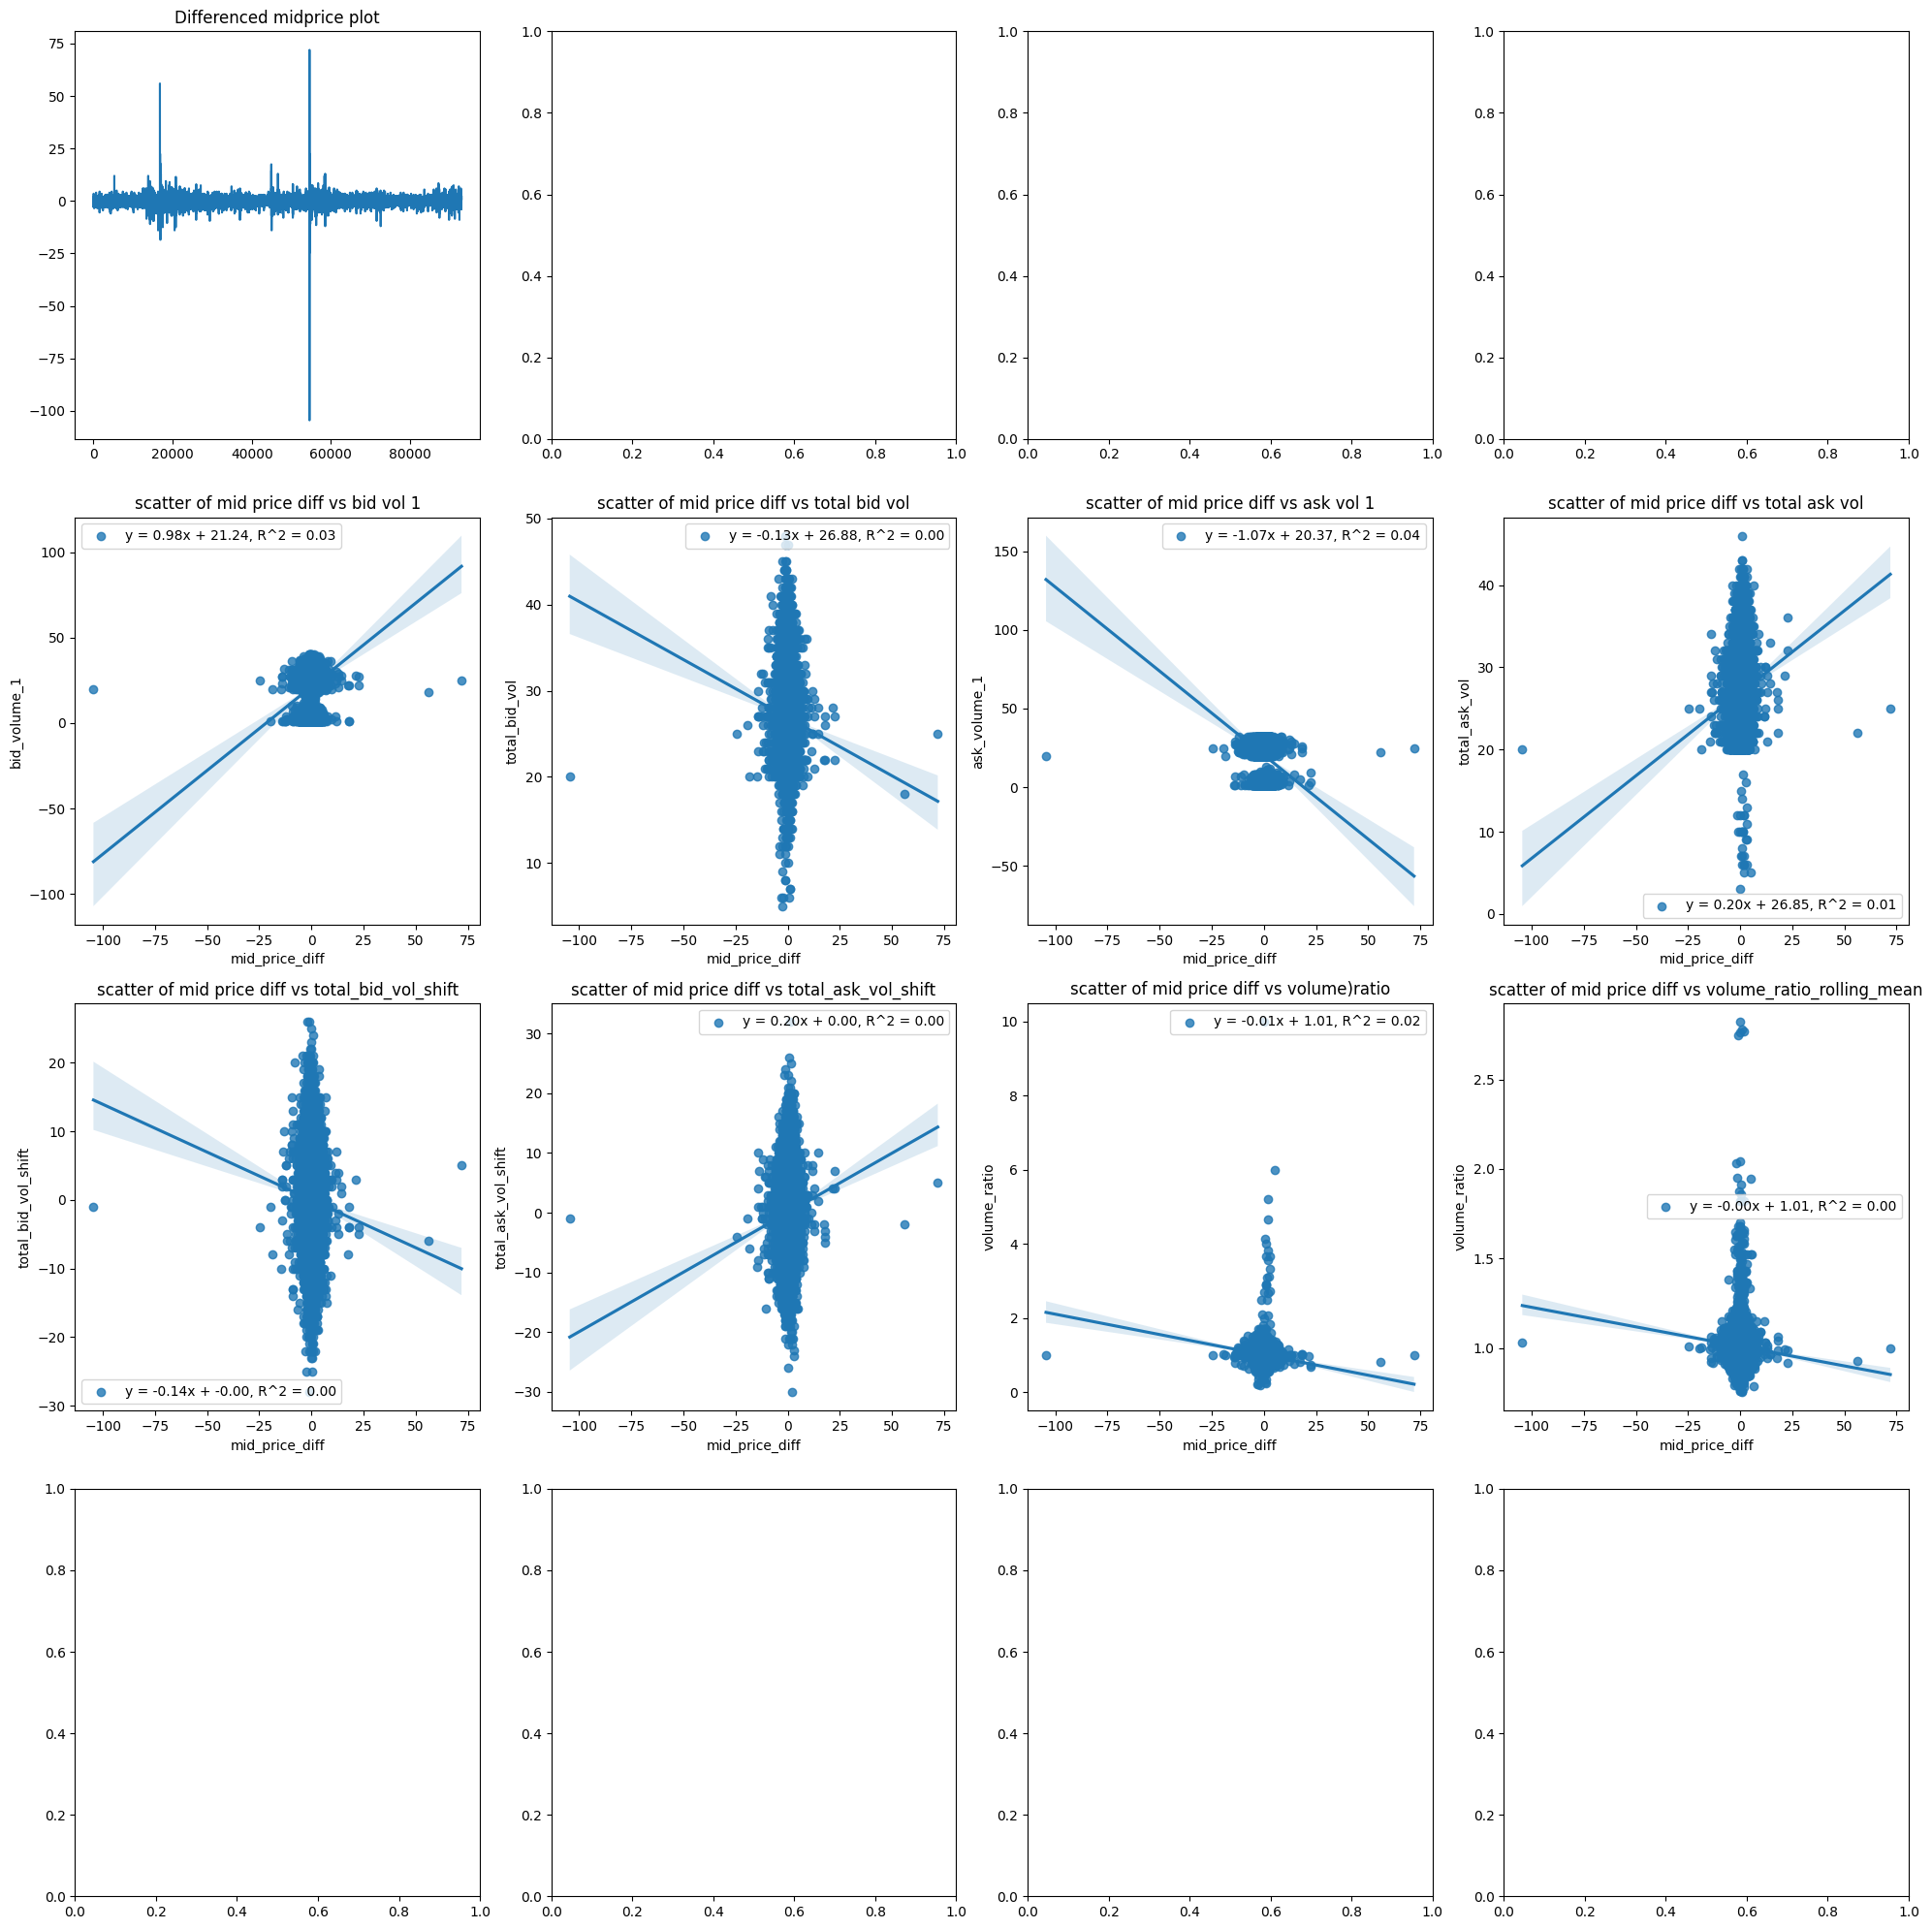

In [76]:
from scipy.stats import linregress
fig,ax = plt.subplots(nrows=4,ncols=4,figsize=(20,20))
changes = squid_data.mid_price.diff().shift(-1)
squid_data['mid_price_diff'] = changes
ax[0,0].plot(changes)
ax[0,0].set_title('Differenced midprice plot')

def basic_volume_price_scatters(ax):
    df = squid_data[['mid_price_diff','bid_volume_1']].dropna()
    slope, intercept, r, p, stderr = linregress(df['mid_price_diff'].values,df['bid_volume_1'].values)
    text = f"y = {slope:.2f}x + {intercept:.2f}, R^2 = {r**2:.2f}"
    sns.regplot(df,x='mid_price_diff',y='bid_volume_1',ax=ax[1,0], label=text)
    ax[1,0].legend()
    ax[1,0].set_title('scatter of mid price diff vs bid vol 1')

    total_volume = squid_data[['bid_volume_1','bid_volume_2','bid_volume_3']].sum(axis=1)
    squid_data['total_bid_vol'] = total_volume
    df = squid_data[['mid_price_diff','total_bid_vol']].dropna()
    slope, intercept, r, p, stderr = linregress(df['mid_price_diff'].values,df['total_bid_vol'].values)
    text = f"y = {slope:.2f}x + {intercept:.2f}, R^2 = {r**2:.2f}"
    sns.regplot(df,x='mid_price_diff',y='total_bid_vol',ax=ax[1,1], label=text)
    ax[1,1].legend()
    ax[1,1].set_title('scatter of mid price diff vs total bid vol')

    df = squid_data[['mid_price_diff','ask_volume_1']].dropna()
    slope, intercept, r, p, stderr = linregress(df['mid_price_diff'].values,df['ask_volume_1'].values)
    text = f"y = {slope:.2f}x + {intercept:.2f}, R^2 = {r**2:.2f}"
    sns.regplot(df,x='mid_price_diff',y='ask_volume_1',ax=ax[1,2], label=text)
    ax[1,2].legend()
    ax[1,2].set_title('scatter of mid price diff vs ask vol 1')

    total_volume = squid_data[['ask_volume_1','ask_volume_2','ask_volume_3']].sum(axis=1)
    squid_data['total_ask_vol'] = total_volume
    df = squid_data[['mid_price_diff','total_ask_vol']].dropna()
    slope, intercept, r, p, stderr = linregress(df['mid_price_diff'].values,df['total_ask_vol'].values)
    text = f"y = {slope:.2f}x + {intercept:.2f}, R^2 = {r**2:.2f}"
    sns.regplot(df,x='mid_price_diff',y='total_ask_vol',ax=ax[1,3], label=text)
    ax[1,3].legend()
    ax[1,3].set_title('scatter of mid price diff vs total ask vol')

def total_volume_scatters(ax):
    total_volume = squid_data[['bid_volume_1','bid_volume_2','bid_volume_3']].sum(axis=1)
    squid_data['total_bid_vol_shift'] = total_volume.diff()
    df = squid_data[['mid_price_diff','total_bid_vol_shift']].dropna()
    slope, intercept, r, p, stderr = linregress(df['mid_price_diff'].values,df['total_bid_vol_shift'].values)
    text = f"y = {slope:.2f}x + {intercept:.2f}, R^2 = {r**2:.2f}"
    sns.regplot(df,x='mid_price_diff',y='total_bid_vol_shift',ax=ax[2,0], label=text)
    ax[2,0].legend()
    ax[2,0].set_title('scatter of mid price diff vs total_bid_vol_shift')


    total_volume = squid_data[['ask_volume_1','ask_volume_2','ask_volume_3']].sum(axis=1)
    squid_data['total_ask_vol_shift'] = total_volume.diff()
    df = squid_data[['mid_price_diff','total_ask_vol_shift']].dropna()
    slope, intercept, r, p, stderr = linregress(df['mid_price_diff'].values,df['total_ask_vol_shift'].values)
    text = f"y = {slope:.2f}x + {intercept:.2f}, R^2 = {r**2:.2f}"
    sns.regplot(df,x='mid_price_diff',y='total_ask_vol_shift',ax=ax[2,1], label=text)
    ax[2,1].legend()
    ax[2,1].set_title('scatter of mid price diff vs total_ask_vol_shift')

    volume_ratio = squid_data[['bid_volume_1','bid_volume_2','bid_volume_3']].sum(axis=1)/squid_data[['ask_volume_1','ask_volume_2','ask_volume_3']].sum(axis=1)
    squid_data['volume_ratio'] = volume_ratio
    df = squid_data[['mid_price_diff','volume_ratio']].dropna()
    slope, intercept, r, p, stderr = linregress(df['mid_price_diff'].values,df['volume_ratio'].values)
    text = f"y = {slope:.2f}x + {intercept:.2f}, R^2 = {r**2:.2f}"
    sns.regplot(df,x='mid_price_diff',y='volume_ratio',ax=ax[2,2], label=text)
    ax[2,2].legend()
    ax[2,2].set_title('scatter of mid price diff vs volume)ratio')

    volume_ratio = squid_data[['bid_volume_1','bid_volume_2','bid_volume_3']].sum(axis=1)/squid_data[['ask_volume_1','ask_volume_2','ask_volume_3']].sum(axis=1)
    squid_data['volume_ratio'] = volume_ratio.rolling(5).mean()
    df = squid_data[['mid_price_diff','volume_ratio']].dropna()
    slope, intercept, r, p, stderr = linregress(df['mid_price_diff'].values,df['volume_ratio'].values)
    text = f"y = {slope:.2f}x + {intercept:.2f}, R^2 = {r**2:.2f}"
    sns.regplot(df,x='mid_price_diff',y='volume_ratio',ax=ax[2,3], label=text)
    ax[2,3].legend()
    ax[2,3].set_title('scatter of mid price diff vs volume_ratio_rolling_mean')

basic_volume_price_scatters(ax)
total_volume_scatters(ax)
fig.tight_layout()

In [94]:
squid_data["highest_vol_bid_idx"] = squid_data.apply(lambda row : 1 + np.argmax([row.fillna(0)[f"bid_volume_{i}"] for i in range(1,4)]),axis=1)
squid_data["highest_vol_bid"] = squid_data.apply(lambda row : row[f"bid_price_{row['highest_vol_bid_idx']}"],axis=1)

squid_data["highest_vol_ask_idx"] = squid_data.apply(lambda row : 1 + np.argmax([row.fillna(0)[f"ask_volume_{i}"] for i in range(1,4)]),axis=1)
squid_data["highest_vol_ask"] = squid_data.apply(lambda row : row[f"ask_price_{row['highest_vol_ask_idx']}"],axis=1)

C:\Users\Conrad\AppData\Local\Temp\ipykernel_5492\4208327603.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  squid_data["highest_vol_bid_idx"] = squid_data.apply(lambda row : 1 + np.argmax([row.fillna(0)[f"bid_volume_{i}"] for i in range(1,4)]),axis=1)
C:\Users\Conrad\AppData\Local\Temp\ipykernel_5492\4208327603.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  squid_data["highest_vol_bid"] = squid_data.apply(lambda row : row[f"bid_price_{row['highest_vol_bid_idx']}"],axis=1)
C:\Users\Conrad\AppData\L

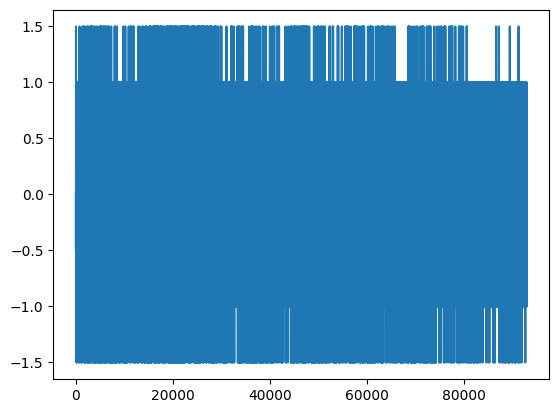

In [96]:
# plt.plot(squid_data.mid_price)
# plt.plot((squid_data['highest_vol_ask']+squid_data['highest_vol_bid'])/2)
plt.plot(squid_data.mid_price-(squid_data['highest_vol_ask']+squid_data['highest_vol_bid'])/2)

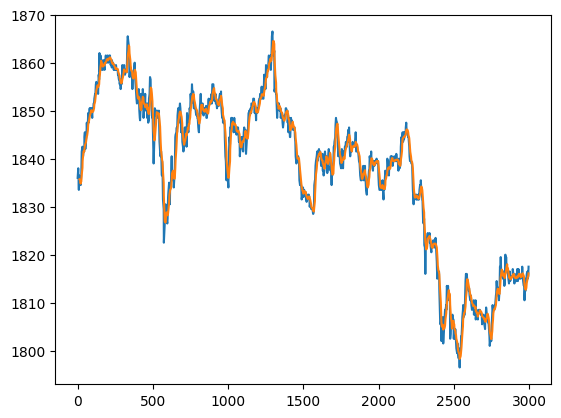

In [99]:
squid_data = processor.activities_log[processor.activities_log['product'] == "SQUID_INK"]
# squid_data["highest_vol_bid_idx"] = squid_data.apply(lambda row : 1 + np.argmax([row.fillna(0)[f"bid_volume_{i}"] for i in range(1,4)]),axis=1)
# squid_data["highest_vol_bid"] = squid_data.apply(lambda row : row[f"bid_price_{row['highest_vol_bid_idx']}"],axis=1)

# squid_data["highest_vol_ask_idx"] = squid_data.apply(lambda row : 1 + np.argmax([row.fillna(0)[f"ask_volume_{i}"] for i in range(1,4)]),axis=1)
# squid_data["highest_vol_ask"] = squid_data.apply(lambda row : row[f"ask_price_{row['highest_vol_ask_idx']}"],axis=1)
plt.plot(squid_data.mid_price)
plt.plot(squid_data.mid_price.rolling(5).mean())

# plt.plot((squid_data['highest_vol_ask']+squid_data['highest_vol_bid'])/2)